In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
train_path = '/content/drive/MyDrive/Dataset/train/'
valid_path = '/content/drive/MyDrive/Dataset/test/'

In [9]:
import os
print("Train folders:", os.listdir(train_path))
print("Test folders:", os.listdir(valid_path))

Train folders: ['Corn_(maize)___healthy', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Northern_Leaf_Blight']
Test folders: ['Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_']


In [11]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob
from matplotlib.image import imread
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd

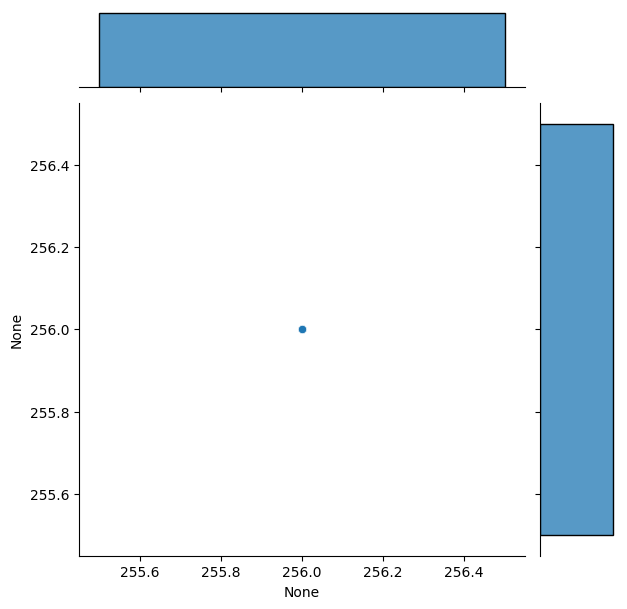

In [12]:
# dimension_check
dim1 = []
dim2 = []

for image_filename in os.listdir(valid_path + 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot'):
    img = imread(valid_path + 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot/' + image_filename)
    d1, d2, colors = img.shape
    dim1.append(d1)
    dim2.append(d2)

# Fixed: use keyword arguments (x=, y=) to avoid deprecation warning
sns.jointplot(x=dim1, y=dim2)

In [13]:
# FIX: Changed from 244 to 224 (standard VGG16 input size)
IMAGE_SIZE = [224, 224]
folders = glob(train_path + '/*')

In [14]:
vgg = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)
for layer in vgg.layers:
    layer.trainable = False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [15]:
x = Flatten()(vgg.output)
# x = Dense(1000, activation='relu')(x)
prediction = Dense(len(folders), activation='softmax')(x)

# create a model object
model = Model(inputs=vgg.input, outputs=prediction)

# view the structure of the model
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       100,356 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,815,044 (56.51 MB)

 Trainable params: 100,356 (392.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [16]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [17]:
# FIX: Use preprocess_input (VGG16's own normalization) instead of rescale=1./255
# VGG16 was trained with mean subtraction, not simple scaling
traindata_gen = ImageDataGenerator(
    rotation_range=10,
    preprocessing_function=preprocess_input,  # replaces rescale=1./255
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    fill_mode='nearest'
)

testdata_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input  # replaces rescale=1./255
)

In [18]:
training_set = traindata_gen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 6776 images belonging to 4 classes.


In [19]:
training_set.class_indices

{'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 0,
 'Corn_(maize)___Common_rust_': 1,
 'Corn_(maize)___Northern_Leaf_Blight': 2,
 'Corn_(maize)___healthy': 3}

In [20]:
testing_set = testdata_gen.flow_from_directory(
    valid_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 1834 images belonging to 4 classes.


In [21]:
# FIX: Replace deprecated fit_generator with model.fit
result = model.fit(
    training_set,
    validation_data=testing_set,
    epochs=5,
    steps_per_epoch=len(training_set),
    validation_steps=len(testing_set)
)

Epoch 1/5
212/212 ━━━━━━━━━━━━━━━━━━━━ 4848s 23s/step - accuracy: 0.9141 - loss: 1.2940 - val_accuracy: 0.9384 - val_loss: 1.4251
Epoch 2/5
212/212 ━━━━━━━━━━━━━━━━━━━━ 133s 628ms/step - accuracy: 0.9585 - loss: 0.8088 - val_accuracy: 0.9586 - val_loss: 1.0126
Epoch 3/5
212/212 ━━━━━━━━━━━━━━━━━━━━ 150s 670ms/step - accuracy: 0.9693 - loss: 0.7552 - val_accuracy: 0.9613 - val_loss: 1.1099
Epoch 4/5
212/212 ━━━━━━━━━━━━━━━━━━━━ 133s 627ms/step - accuracy: 0.9686 - loss: 0.7055 - val_accuracy: 0.9455 - val_loss: 1.8226
Epoch 5/5
212/212 ━━━━━━━━━━━━━━━━━━━━ 132s 623ms/step - accuracy: 0.9752 - loss: 0.5837 - val_accuracy: 0.9569 - val_loss: 1.3924


<Axes: >

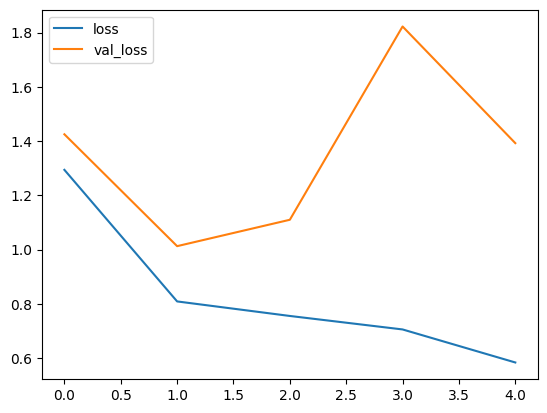

In [22]:
losses = pd.DataFrame(model.history.history)
losses[['loss', 'val_loss']].plot()

In [23]:
model.metrics_names

['loss', 'compile_metrics']

In [27]:
# Predict probabilities for the entire test set
y_pred_probs = model.predict(testing_set)
# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels from the generator
y_true = testing_set.classes

58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 227ms/step


In [28]:
from sklearn.metrics import classification_report, accuracy_score

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print("Test Accuracy:", accuracy)

# Classification report (precision, recall, F1)
class_labels = list(training_set.class_indices.keys())
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

Test Accuracy: 0.9569247546346783

Classification Report:

                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.93      0.92       409
                       Corn_(maize)___Common_rust_       1.00      0.96      0.98       485
               Corn_(maize)___Northern_Leaf_Blight       0.91      0.95      0.93       475
                            Corn_(maize)___healthy       1.00      0.99      0.99       465

                                          accuracy                           0.96      1834
                                         macro avg       0.96      0.96      0.96      1834
                                      weighted avg       0.96      0.96      0.96      1834



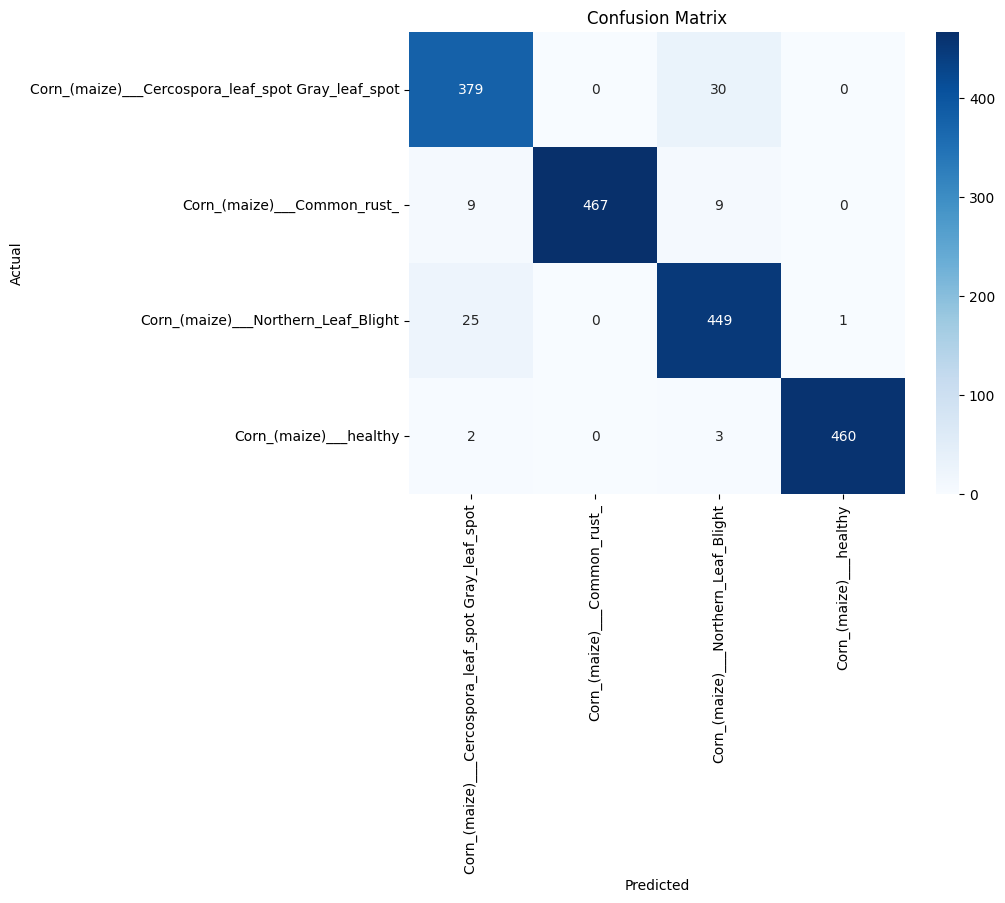

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

58/58 ━━━━━━━━━━━━━━━━━━━━ 13s 214ms/step
===== Test Accuracy =====
Accuracy: 0.9569247546346783

===== Classification Report =====
                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.93      0.92       409
                       Corn_(maize)___Common_rust_       1.00      0.96      0.98       485
               Corn_(maize)___Northern_Leaf_Blight       0.91      0.95      0.93       475
                            Corn_(maize)___healthy       1.00      0.99      0.99       465

                                          accuracy                           0.96      1834
                                         macro avg       0.96      0.96      0.96      1834
                                      weighted avg       0.96      0.96      0.96      1834



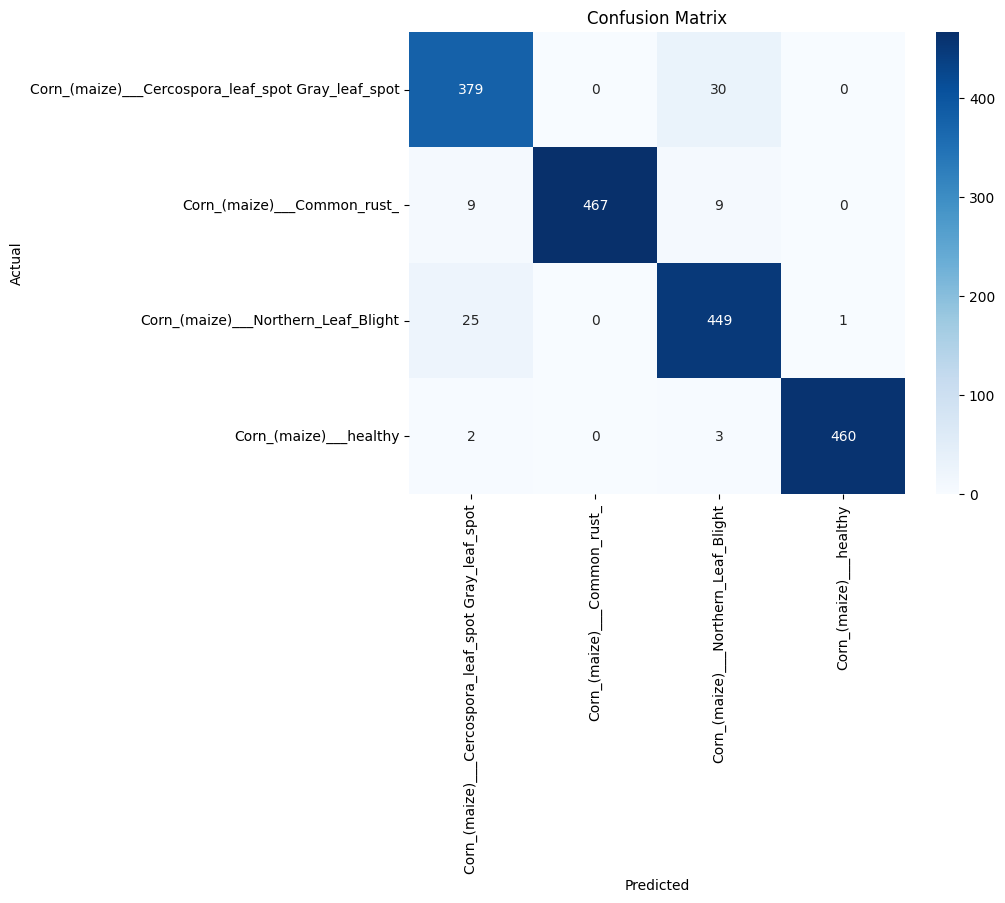

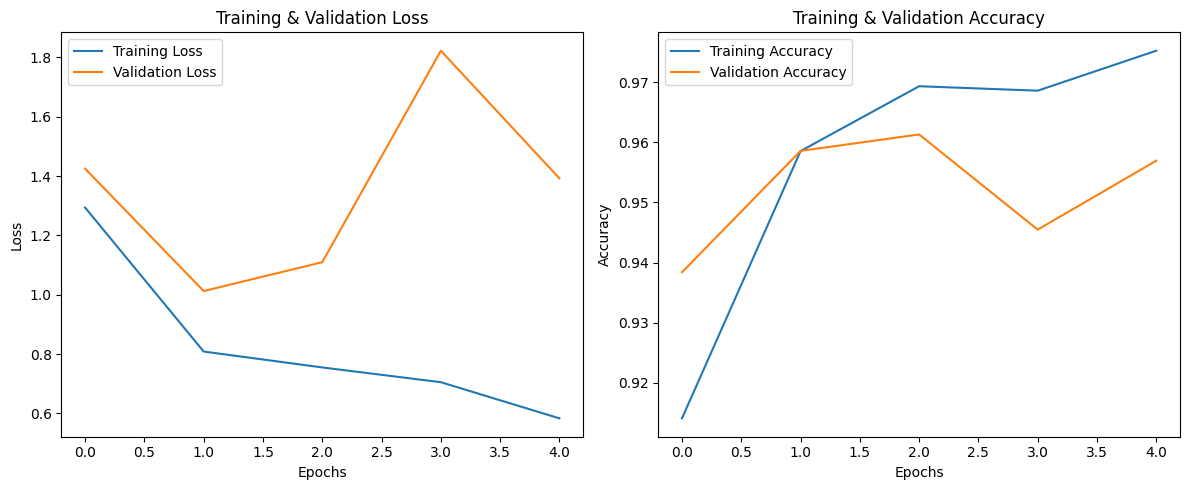

In [37]:
# =========================
# Evaluation Metrics & Curves
# =========================

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. Predict on the test set ---
y_pred_probs = model.predict(testing_set)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = testing_set.classes
class_labels = list(training_set.class_indices.keys())

# --- 2. Print Accuracy & Classification Report ---
print("===== Test Accuracy =====")
print("Accuracy:", accuracy_score(y_true, y_pred))

print("\n===== Classification Report =====")
print(classification_report(y_true, y_pred, target_names=class_labels))

# --- 3. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# --- 4. Training & Validation Curves ---
history_df = pd.DataFrame(result.history)  # 'result' is from model.fit
plt.figure(figsize=(12,5))

# Loss curve
plt.subplot(1,2,1)
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy curve
plt.subplot(1,2,2)
plt.plot(history_df['accuracy'], label='Training Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
from sklearn.metrics import classification_report, accuracy_score

# Predict on test set
y_pred_probs = model.predict(testing_set)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = testing_set.classes
class_labels = list(training_set.class_indices.keys())

# Save metrics to a text file
with open('/content/drive/MyDrive/maize_metrics.txt', 'w') as f:
    f.write("===== Test Accuracy =====\n")
    f.write(f"Accuracy: {accuracy_score(y_true, y_pred)}\n\n")
    f.write("===== Classification Report =====\n")
    f.write(classification_report(y_true, y_pred, target_names=class_labels))

print("Metrics saved to maize_metrics.txt in your Google Drive")

58/58 ━━━━━━━━━━━━━━━━━━━━ 14s 230ms/step
Metrics saved to maize_metrics.txt in your Google Drive


In [39]:
# =========================
# Presentation-ready Metrics & Plots
# =========================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# --- 1. Predict on test set ---
y_pred_probs = model.predict(testing_set)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = testing_set.classes
class_labels = list(training_set.class_indices.keys())

# --- 2. Classification Report as DataFrame ---
report_dict = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose().round(2)

# Save metrics table as PNG
fig, ax = plt.subplots(figsize=(8, len(report_df)*0.5))  # auto-height based on number of classes
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=report_df.values,
                 colLabels=report_df.columns,
                 rowLabels=report_df.index,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
plt.title("Classification Metrics Table", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/maize_metrics_table.png')
plt.close()
print("Metrics table saved as 'maize_metrics_table.png'")

# --- 3. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/maize_confusion_matrix.png')
plt.close()
print("Confusion matrix saved as 'maize_confusion_matrix.png'")

# --- 4. Training & Validation Curves ---
history_df = pd.DataFrame(result.history)  # 'result' from model.fit
plt.figure(figsize=(12,5))

# Loss curve
plt.subplot(1,2,1)
plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy curve
plt.subplot(1,2,2)
plt.plot(history_df['accuracy'], label='Training Accuracy')
plt.plot(history_df['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/maize_training_curves.png')
plt.close()
print("Training curves saved as 'maize_training_curves.png'")

58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 199ms/step
Metrics table saved as 'maize_metrics_table.png'
Confusion matrix saved as 'maize_confusion_matrix.png'
Training curves saved as 'maize_training_curves.png'


In [41]:
model.save('/content/drive/MyDrive/Dataset/maize_disease_detection_new_model.h5')

In [49]:
import matplotlib.pyplot as plt

# Example: training curves
plt.figure(figsize=(8,6))
plt.plot(result.history['accuracy'], label='Train Accuracy')
plt.plot(result.history['val_accuracy'], label='Val Accuracy')
plt.plot(result.history['loss'], label='Train Loss')
plt.plot(result.history['val_loss'], label='Val Loss')
plt.title("Training Curves")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.savefig('/content/maize_training_curves.png')  # save in Colab local folder
plt.close()

# Confusion matrix example
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = testing_set.classes
y_pred_probs = model.predict(testing_set)
y_pred = y_pred_probs.argmax(axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig('/content/maize_confusion_matrix.png')
plt.close()

58/58 ━━━━━━━━━━━━━━━━━━━━ 12s 202ms/step


In [52]:
import pandas as pd
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=list(training_set.class_indices.keys()), output_dict=True)
report_df = pd.DataFrame(report).transpose()

fig, ax = plt.subplots(figsize=(8, len(report_df)*0.5))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=report_df.round(2).values,
                 colLabels=report_df.columns,
                 rowLabels=report_df.index,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
plt.title("Classification Metrics Table", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('/content/maize_metrics_table.png')
plt.close()

In [53]:
from google.colab import files

# Download plots
files.download('/content/maize_training_curves.png')
files.download('/content/maize_confusion_matrix.png')
files.download('/content/maize_metrics_table.png')

# Optional: Download model
files.download('/content/maize_disease_detection_new_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from tensorflow.keras.models import load_model
model.save('maize_disease_detection_new_model.h5')


# Testing for a single image


In [36]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

# Full path from Google Drive
img_path = '/content/drive/MyDrive/Dataset/test/Corn_(maize)___healthy/d976fc74-23c2-4c34-a068-db120a61fe0f___R.S_HL 5561 copy_flipLR.jpg'

# Load and preprocess
img = image.load_img(img_path, target_size=IMAGE_SIZE)
img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)
img = preprocess_input(img)

# Predict
pred = model.predict(img)

# Map to label
class_labels = list(training_set.class_indices.keys())
pred_class = class_labels[np.argmax(pred)]
print("Predicted class:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted class: Corn_(maize)___healthy
